In [1]:
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('D:\\Salzburg\\TexSense\\Messungen\\IMU\\treadmill_finki\\finki__18.txt', sep='\t', header=1) 

In [3]:
lf = df[df.columns[df.columns.str.contains(pat = 'L_Foot')]]
rf = df[df.columns[df.columns.str.contains(pat = 'R_Foot')]]

In [4]:
# filter for midswing detection
b, a = butter(2, 90 / 2000, btype='low')
gyr_y_filt = filtfilt(b, a, rf.iloc[:,4], axis=0)

In [5]:
# midswing
midswing, _ = find_peaks(gyr_y_filt, distance = 2000 * 60 / 100)

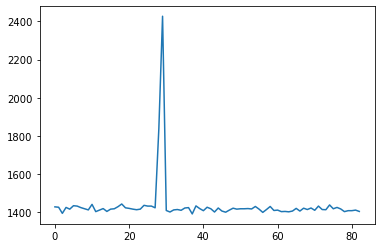

In [62]:
# check
plt.plot(np.diff(midswing, n=1))

In [7]:
gyr_norm = np.linalg.norm(rf.iloc[:,3:6], axis = 1)
# midstance
midstance=[]
for i in range(len(midswing)-1):
    midstance.append(np.argmin(gyr_norm[midswing[i]:midswing[i]+(2*(midswing[i+1]-midswing[i]))//5])+midswing[i])
midstance = np.array(midstance)

In [8]:
midstance

array([   717,   2148,   3566,   4966,   6366,   7801,   9229,  10664,
        12099,  13513,  14928,  16341,  17748,  19161,  20569,  22004,
        23404,  24832,  26253,  27709,  29095,  30548,  31965,  33359,
        34793,  36235,  37663,  39098,  40526,  43181,  44768,  46203,
        47582,  48996,  50403,  51803,  53224,  54666,  56059,  57506,
        58896,  60322,  61729,  63150,  64564,  65971,  67385,  68778,
        70199,  71613,  73020,  74441,  75890,  77310,  78703,  80133,
        81539,  82960,  84353,  85789,  87223,  88623,  90037,  91437,
        92830,  94237,  95672,  97065,  98465,  99907, 101321, 102749,
       104142, 105589, 106977, 108412, 109856, 111261, 112697, 114103,
       115495, 116908, 118310], dtype=int64)

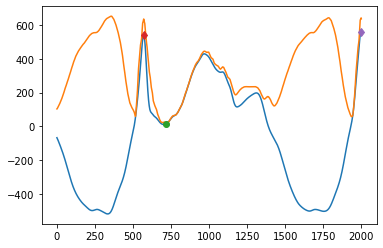

In [38]:
plt.plot(gyr_y_filt[:2000])
plt.plot(gyr_norm[:2000])
plt.plot(midstance[0], gyr_y_filt[:2000][midstance[0]], 'o')
plt.plot(midswing[0], gyr_y_filt[:2000][midswing[0]], 'd')
plt.plot(midswing[1], gyr_y_filt[:2000][midswing[1]], 'd')

In [9]:
IC_start = []
for i in range(len(midstance)):
    IC_start.append(np.min(np.where(gyr_y_filt[midswing[i]:midstance[i+1]]<0))+midstance[i])
IC_start=np.array(IC_start)

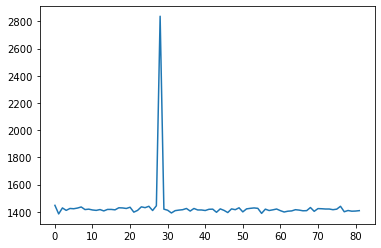

In [10]:
plt.plot(np.diff(IC_start, n=1))

In [11]:
#midstance = np.delete(midstance, 0)
print(IC_start[:10])
print(midstance[:10])

[ 1389  2837  4222  5651  7062  8487  9910 11338 12774 14191]
[  717  2148  3566  4966  6366  7801  9229 10664 12099 13513]


In [12]:
midstance

array([   717,   2148,   3566,   4966,   6366,   7801,   9229,  10664,
        12099,  13513,  14928,  16341,  17748,  19161,  20569,  22004,
        23404,  24832,  26253,  27709,  29095,  30548,  31965,  33359,
        34793,  36235,  37663,  39098,  40526,  43181,  44768,  46203,
        47582,  48996,  50403,  51803,  53224,  54666,  56059,  57506,
        58896,  60322,  61729,  63150,  64564,  65971,  67385,  68778,
        70199,  71613,  73020,  74441,  75890,  77310,  78703,  80133,
        81539,  82960,  84353,  85789,  87223,  88623,  90037,  91437,
        92830,  94237,  95672,  97065,  98465,  99907, 101321, 102749,
       104142, 105589, 106977, 108412, 109856, 111261, 112697, 114103,
       115495, 116908, 118310], dtype=int64)

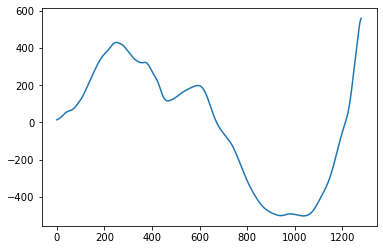

In [13]:
# TO_end
temp = gyr_y_filt[midstance[0]:midswing[1]]
plt.plot(gyr_y_filt[midstance[0]:midswing[1]])

In [14]:
np.max(np.where(temp<0))+1

1214

In [15]:
TO_end = []
for i in range(len(midstance)):
    TO_end.append(np.max(np.where(gyr_y_filt[midstance[i]:midswing[i+1]]<0))+midstance[i]+1)
TO_end=np.array(TO_end)

In [16]:
print(IC_start[:10], IC_start.shape)
print(midstance[:10], midstance.shape)
print(TO_end[:10],  TO_end.shape)

[ 1389  2837  4222  5651  7062  8487  9910 11338 12774 14191] (83,)
[  717  2148  3566  4966  6366  7801  9229 10664 12099 13513] (83,)
[ 1931  3360  4753  6177  7596  9030 10447 11881 13305 14721] (83,)


In [17]:
IC_start.shape

(83,)

In [26]:
print(midswing[:10], midswing.shape)
print(midstance[:10], midstance.shape)

[  570  1998  3424  4818  6243  7659  9093 10525 11949 13367] (84,)
[  717  2148  3566  4966  6366  7801  9229 10664 12099 13513] (83,)


In [ ]:
ic_wind=[]
to_wind=[]
for i in range(len(midstance)):
    ic_wind.append([midswing[i], midstance[i]])

In [35]:
gyr_norm = np.linalg.norm(rf.iloc[:,3:6], axis = 1)
norm_filt = filtfilt(b, a, gyr_norm, axis=0)

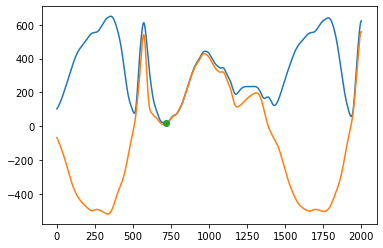

In [37]:
plt.plot(norm_filt[:2000])
plt.plot(gyr_y_filt[:2000])
plt.plot(midstance[0], norm_filt[:2000][midstance[0]], 'o')

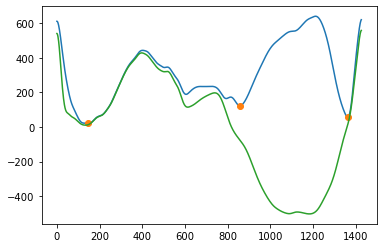

In [54]:
peaks, _ = find_peaks(-norm_filt[midswing[0]:midswing[1]], prominence=80)
plt.plot(norm_filt[midswing[0]:midswing[1]])
plt.plot(peaks, norm_filt[midswing[0]:midswing[1]][peaks], 'o')
plt.plot(gyr_y_filt[midswing[0]:midswing[1]])
#plt.plot(midswing[:1], gyr_y_filt[midswing[0]:midswing[1]][midswing[:1]], 'd')

In [56]:
TO_end=[]
IC_start=[]
mid=[]
for i in range(len(midswing)-1):
    peaks, _ = find_peaks(-gyr_norm[midswing[i]:midswing[i+1]], prominence = 80)
    mid.append(peaks[0]+midswing[i])
    TO_end.append(peaks[1]+midswing[i])
    IC_start.append(peaks[2]+midswing[i])

In [58]:
print(IC_start[:10], len(IC_start))
print(mid[:10], len(mid))
print(TO_end[:10], len(TO_end))


[1937, 3366, 4762, 5673, 7604, 8519, 10466, 11897, 13316, 14728] 83
[717, 2148, 3566, 4966, 6366, 7801, 9229, 10664, 12099, 13513] 83
[1427, 2864, 4255, 5400, 7088, 8249, 9936, 11374, 12802, 14211] 83


In [59]:
mid = mid[1:]
TO_end = TO_end[1:]
IC_start = IC_start[:-1]

In [60]:
print(IC_start[:10], len(IC_start))
print(mid[:10], len(mid))
print(TO_end[:10], len(TO_end))

[1937, 3366, 4762, 5673, 7604, 8519, 10466, 11897, 13316, 14728] 82
[2148, 3566, 4966, 6366, 7801, 9229, 10664, 12099, 13513, 14928] 82
[2864, 4255, 5400, 7088, 8249, 9936, 11374, 12802, 14211, 15641] 82


In [ ]:
window = {}
for i in range(len(IC_start)):
    window['step'+str(i)]=


In [71]:
#IC=[]
#for i in range(len(IC_start)):
sl = rf[IC_start[i]:mid[i]]

In [78]:
sl.iloc[:,4].idxmin()

118303

In [81]:
s=sl.iloc[:,4]

118219

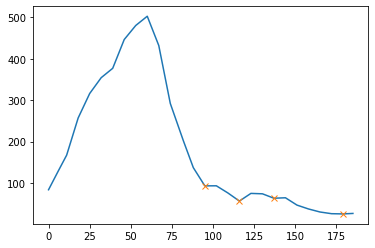

In [88]:
peaks, _ = find_peaks(-s, height = -100)
plt.plot(s.values)
plt.plot(peaks, s.values[peaks], 'x')
peaks[0]+s.index[0]

In [102]:
sl

,R_Foot_ImuAcc :X(g):,R_Foot_ImuAcc :Y(g):,R_Foot_ImuAcc :Z(g):,R_Foot_Gyro :X(D/s):,R_Foot_Gyro :Y(D/s):,R_Foot_Gyro :Z(D/s):,R_Foot_Mag :X(uT):,R_Foot_Mag :Y(uT):,R_Foot_Mag :Z(uT):
118124,-3.1002,-1.4870,-2.5961,59.9296,83.4463,-29.7948,25.2,-35.4,-27.75
118125,-2.8663,-1.3129,-2.5710,51.5850,91.1806,-26.1151,25.2,-35.4,-27.75
118126,-2.6324,-1.1388,-2.5459,43.2404,98.9149,-22.4355,25.2,-35.4,-27.75
118127,-2.3985,-0.9647,-2.5208,34.8957,106.6491,-18.7558,25.2,-35.4,-27.75
118128,-2.1646,-0.7906,-2.4957,26.5511,114.3834,-15.0761,25.2,-35.4,-27.75
...,...,...,...,...,...,...,...,...,...
118305,-1.1796,0.2727,0.8881,-12.1376,25.4699,-5.6503,-12.9,-54.9,-35.70
118306,-1.2239,0.3056,0.9103,-11.7365,25.6617,-5.3625,-12.9,-54.9,-35.70
118307,-1.2683,0.3385,0.9325,-11.3354,25.8535,-5.0748,-12.9,-54.9,-35.70
118308,-1.3127,0.3713,0.9547,-10.9343,26.0454,-4.7870,-12.9,-54.9,-35.70


In [92]:
sl.index[0]

118124

In [101]:
sl.iloc[:,2].idxmax()

118191

In [106]:
np.argmax(np.linalg.norm(sl.iloc[:,3:6], axis = 1))+sl.index[0]

118184

In [108]:
np.argmax(np.linalg.norm(sl.iloc[:,:3], axis = 1))+sl.index[0]

118191

In [118]:
df = pd.DataFrame(data=None, columns=['IC_1', 'IC_3', 'IC_7', 'IC_8', 'IC_9'])

In [116]:
sl = rf[mid[1]:TO_end[1]]
sl

,R_Foot_ImuAcc :X(g):,R_Foot_ImuAcc :Y(g):,R_Foot_ImuAcc :Z(g):,R_Foot_Gyro :X(D/s):,R_Foot_Gyro :Y(D/s):,R_Foot_Gyro :Z(D/s):,R_Foot_Mag :X(uT):,R_Foot_Mag :Y(uT):,R_Foot_Mag :Z(uT):
3566,-1.2544,0.2363,1.3228,-11.9633,21.7902,-6.7751,-20.7750,-46.35,-33.6750
3567,-1.2009,0.2519,1.3199,-11.6581,22.5227,-6.4874,-20.7429,-46.65,-34.4143
3568,-1.1473,0.2674,1.3169,-11.3529,23.2551,-6.1996,-20.7107,-46.95,-35.1536
3569,-1.0937,0.2830,1.3140,-11.0477,23.9875,-5.9119,-20.6786,-47.25,-35.8929
3570,-1.0401,0.2986,1.3111,-10.7425,24.7200,-5.6241,-20.6464,-47.55,-36.6321
...,...,...,...,...,...,...,...,...,...
4250,-0.4994,0.5093,2.1088,-100.6675,-74.8227,2.2845,80.1000,-16.95,-32.5500
4251,-0.4858,0.5000,2.0991,-98.1562,-77.2380,6.2083,80.1000,-16.95,-32.5500
4252,-0.4722,0.4907,2.0894,-95.6450,-79.6533,10.1321,80.1000,-16.95,-32.5500
4253,-0.4536,0.4964,2.0741,-93.5087,-81.4059,12.8265,80.1000,-16.95,-32.5500


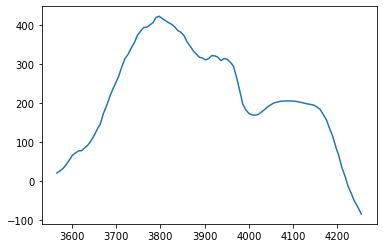

In [117]:
plt.plot(sl.iloc[:,4])

In [128]:
df.loc['halli']=4

In [130]:
af = pd.DataFrame()

In [131]:
af.loc[1,'hallo']=54

In [132]:
af

,hallo
1,54.0
